## Final Project Submission

Please fill out:
* Student name: Susan Nduta
* Student pace: self paced / part time / full time
* Scheduled project review date/time: 
* Instructor name: 
* Blog post URL:


## Load data

In [1]:
import pandas as pd
data = pd.read_csv('train.csv')
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
# Display basic information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## 1. Explore Data Distribution

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
# Summary statistics for SalePrice, TotRmsAbvGrd, and OverallCond
features = ["SalePrice", "TotRmsAbvGrd", "OverallCond"]
data[features].describe()

,SalePrice,TotRmsAbvGrd,OverallCond
count,1460.000000,1460.000000,1460.000000
mean,180921.195890,6.517808,5.575342
std,79442.502883,1.625393,1.112799
min,34900.000000,2.000000,1.000000
25%,129975.000000,5.000000,5.000000
50%,163000.000000,6.000000,5.000000
75%,214000.000000,7.000000,6.000000
max,755000.000000,14.000000,9.000000


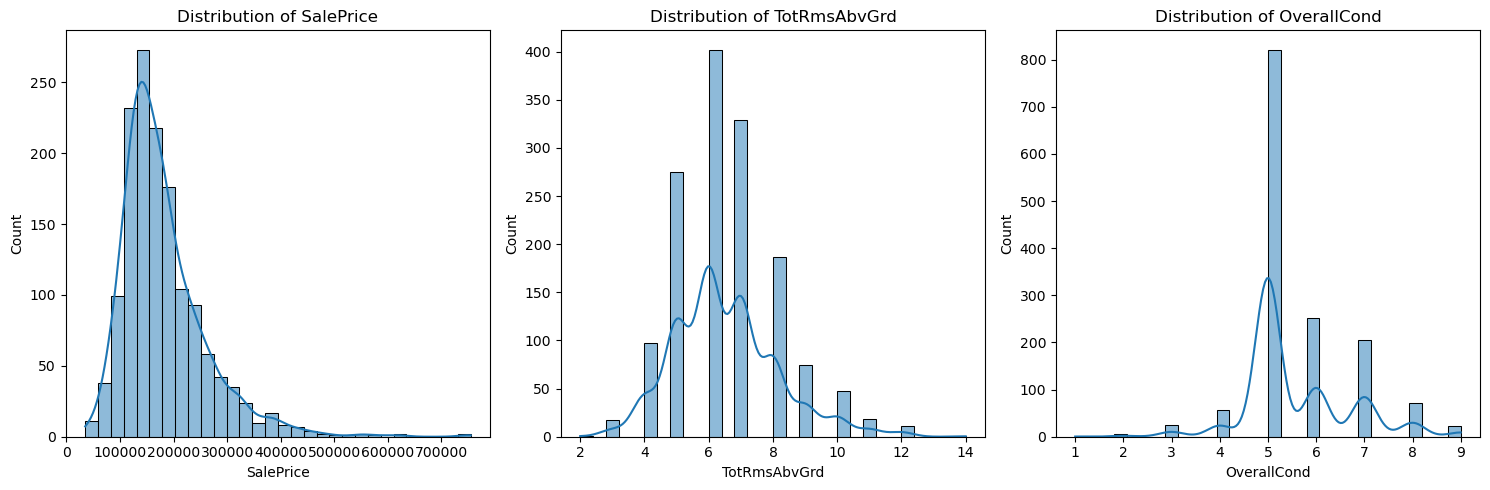

In [4]:
# Histograms for distributions
plt.figure(figsize=(15, 5))
for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## 2. Explore Differences Between Subsets

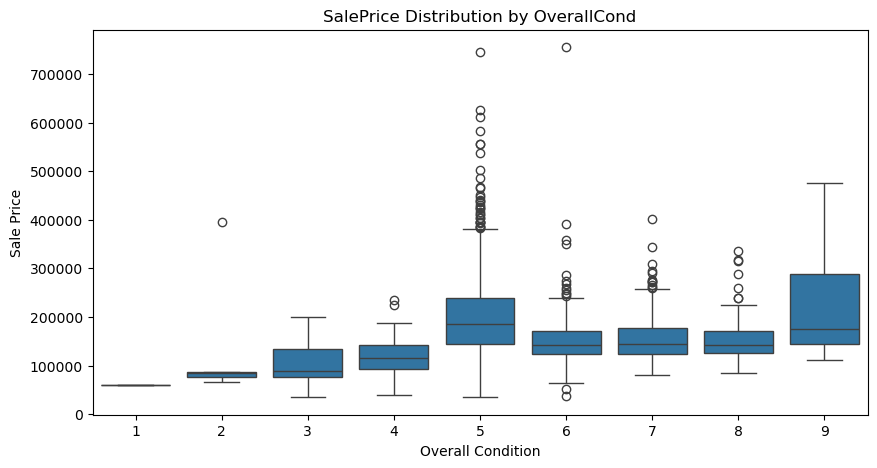

In [5]:
# Boxplot of SalePrice across OverallCond categories
plt.figure(figsize=(10, 5))
sns.boxplot(x=data["OverallCond"], y=data["SalePrice"])
plt.title("SalePrice Distribution by OverallCond")
plt.xlabel("Overall Condition")
plt.ylabel("Sale Price")
plt.show()


## 3. Explore Correlations

In [6]:
# Compute correlation matrix
numeric_data = data.select_dtypes(include=['number'])
numeric_data = numeric_data.drop(columns=['Id'])
correlation_matrix = numeric_data.corr()

# Find strongest positive and negative correlations with SalePrice
strong_pos_corr = correlation_matrix["SalePrice"].sort_values(ascending=False).head(10)
strong_neg_corr = correlation_matrix["SalePrice"].sort_values(ascending=True).head(10)
print("Strongest Positive Correlations:\n", strong_pos_corr)
print("\nStrongest Negative Correlations:\n", strong_neg_corr)

Strongest Positive Correlations:
 SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

Strongest Negative Correlations:
 KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
MSSubClass      -0.084284
OverallCond     -0.077856
YrSold          -0.028923
LowQualFinSF    -0.025606
MiscVal         -0.021190
BsmtHalfBath    -0.016844
BsmtFinSF2      -0.011378
3SsnPorch        0.044584
Name: SalePrice, dtype: float64


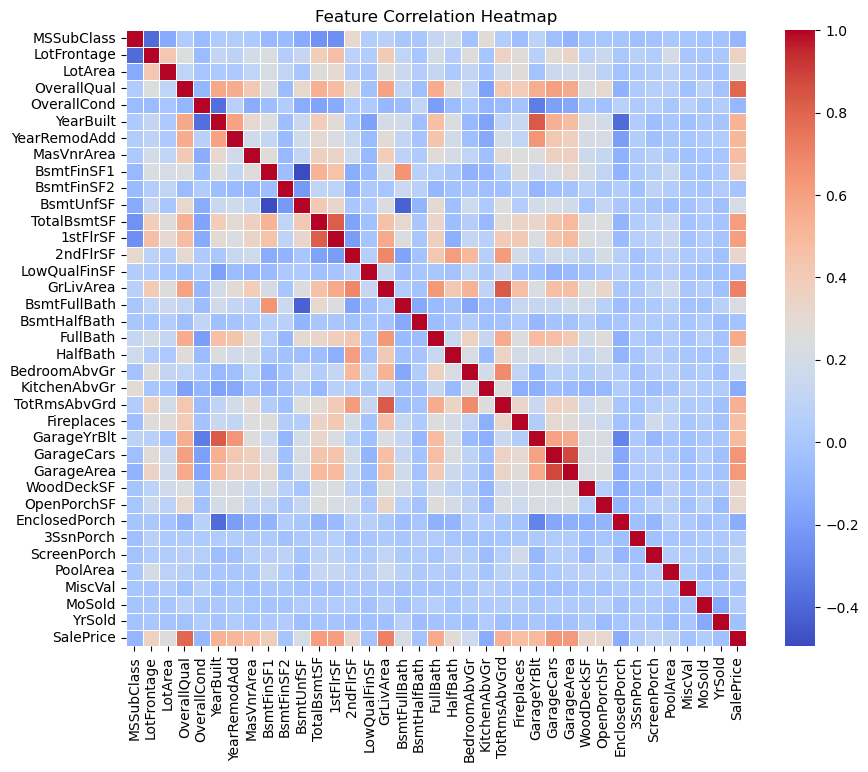

In [7]:
# Heatmap of top correlated features
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

## 4. Engineer and Explore a New Feature

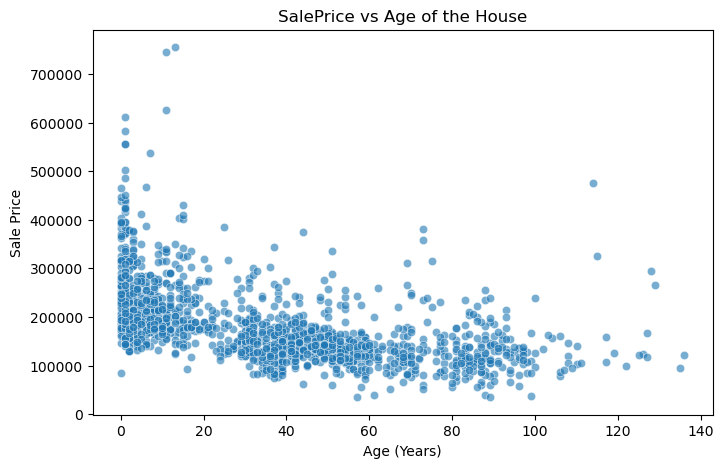

In [8]:
# Create Age feature
data["Age"] = data["YrSold"] - data["YearBuilt"]

# Scatterplot of Age vs SalePrice
plt.figure(figsize=(8, 5))
sns.scatterplot(x=data["Age"], y=data["SalePrice"], alpha=0.6)
plt.title("SalePrice vs Age of the House")
plt.xlabel("Age (Years)")
plt.ylabel("Sale Price")
plt.show()


## 5. Three Polished Visualizations

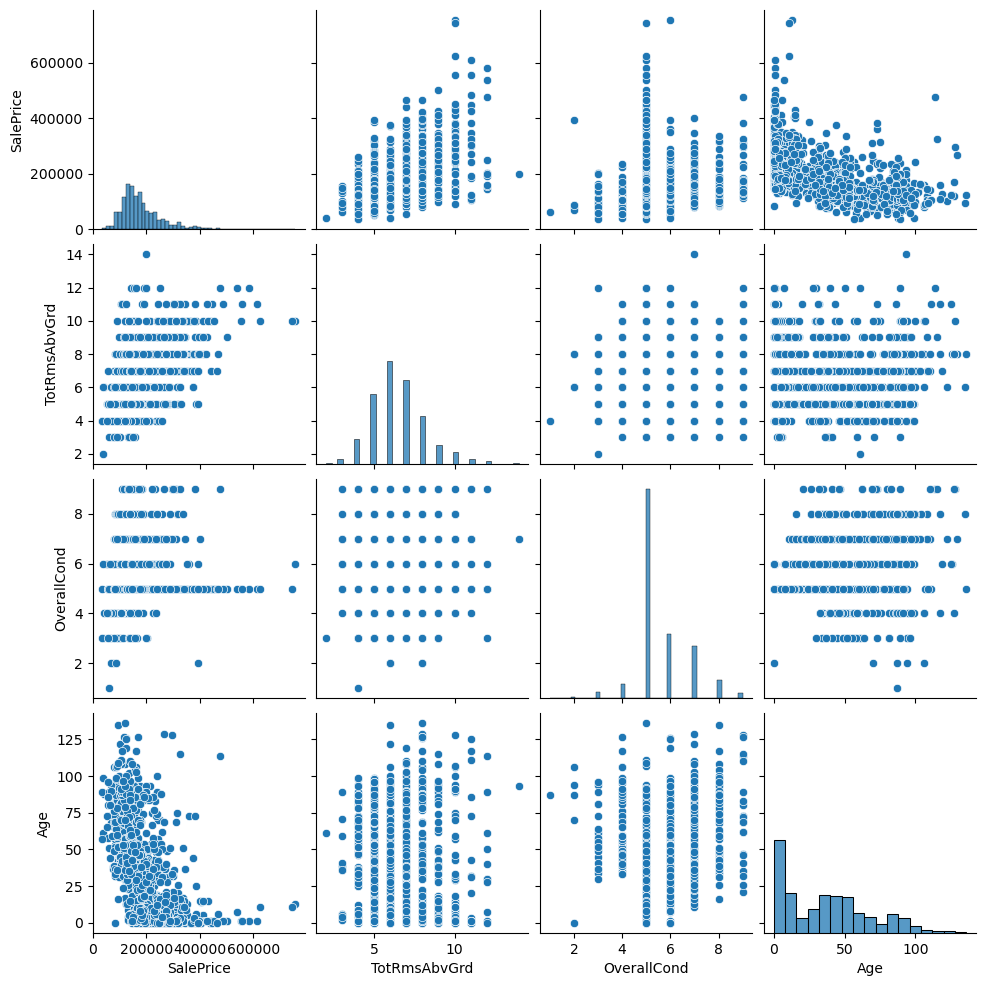

In [9]:
# Pairplot of key variables
sns.pairplot(data[["SalePrice", "TotRmsAbvGrd", "OverallCond", "Age"]])
plt.show()

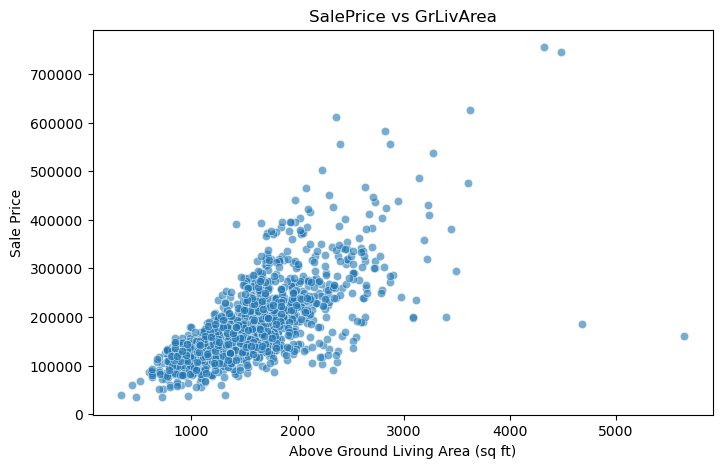

In [10]:
# Sale Price vs. GrLivArea (Above ground living area)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=data["GrLivArea"], y=data["SalePrice"], alpha=0.6)
plt.title("SalePrice vs GrLivArea")
plt.xlabel("Above Ground Living Area (sq ft)")
plt.ylabel("Sale Price")
plt.show()

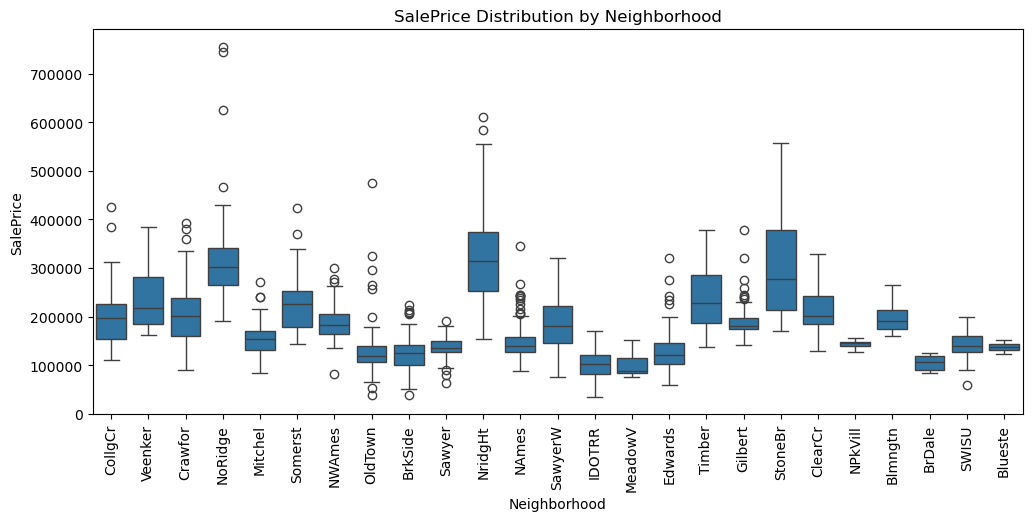

In [11]:
# SalePrice Distribution by Neighborhood
plt.figure(figsize=(12, 5))
sns.boxplot(x=data["Neighborhood"], y=data["SalePrice"])
plt.xticks(rotation=90)
plt.title("SalePrice Distribution by Neighborhood")
plt.show()